In [19]:
#!/usr/bin/env python3
import os, sys, pandas as pd
import matplotlib.pyplot as plt
import re, ast
from math import ceil, sqrt
import seaborn as sns

In [20]:
parent = ""
all_folders = [f for f in os.listdir() if os.path.isdir(f)]

def base_name(folder):
        """Return the experiment base name (everything before the first underscore).

        Examples:
            'exp2' -> 'exp2'
            'exp2_fr' -> 'exp2'
            'exp2_500_1000' -> 'exp2'
        """
        return folder.split('_', 1)[0]

groups = {}
for f in all_folders:
    b = base_name(f)
    groups.setdefault(b, []).append(f)

groups

{'apoptosis': ['apoptosis_synthetic'],
 'exp0': ['exp0', 'exp0_fr', 'exp0_noise', 'exp0_r33', 'exp0_r66'],
 'exp1': ['exp1', 'exp1_fr', 'exp1_r33', 'exp1_r66'],
 'exp2': ['exp2',
  'exp2_eq',
  'exp2_eq_dense',
  'exp2_eq_extradense',
  'exp2_fc',
  'exp2_fr',
  'exp2_hub',
  'exp2_r33',
  'exp2_r66',
  'exp2_sl'],
 'exp3': ['exp3_500_1000',
  'exp3_500_1250',
  'exp3_500_2000',
  'exp3_500_550',
  'exp3_500_800'],
 'exp4': ['exp4_1000_2000',
  'exp4_100_200',
  'exp4_250_500',
  'exp4_500_1000',
  'exp4_600_1200'],
 'exp5': ['exp5_s1000',
  'exp5_s10000',
  'exp5_s2500',
  'exp5_s3500',
  'exp5_s500',
  'exp5_s5000',
  'exp5_s7500',
  'exp5_s9000'],
 'exp6': ['exp6_s10000_eqd',
  'exp6_s2500_eqd',
  'exp6_s5000_eqd',
  'exp6_s7500_eqd'],
 'exp7': ['exp7_25000'],
 'exp': ['exp_test'],
 'expsi': ['expsi_rcp', 'expsi_si'],
 'og': ['og_pdgrapher_data', 'og_pdgrapher_data_fr'],
 'old': ['old'],
 'old exp1': ['old exp1'],
 'pathway': ['pathway_no_fold', 'pathway_no_nd', 'pathway_synthetic']

In [21]:
ideal_groups = {'exp0': ['exp0', 'exp0_noise'],
 'exp1': ['exp1', 'exp1_r33', 'exp1_r66', 'exp1_fr'],
 'exp2': ['exp2', 'exp2_r33', 'exp2_r66', 'exp2_fr', 'exp2_fc', 'exp2_eq', 'exp2_sl', 'exp2_hub'], # 'exp2_eq_extradense', 
 'exp3': ['exp3_500_550', 'exp3_500_800', 'exp3_500_1000',  'exp3_500_1250', 'exp3_500_2000'],
 'exp4': ['exp4_100_200', 'exp4_250_500','exp4_500_1000', 'exp4_600_1200'],
 'exp5': ['exp5_s500', 'exp5_s1000', 'exp5_s2500', 'exp5_s3500', 'exp5_s5000', 'exp5_s7500', 'exp5_s9000', 'exp5_s10000'],
 'expsi': ['expsi_rcp', 'expsi_si'],
 'exp6': ['exp6_s2500_eqd', 'exp6_s5000_eqd', 'exp6_s7500_eqd', 'exp6_s10000_eqd'],
 'pdgrapher': ['pdgrapher_grn', 'pdgrapher_nognn', 'pdgrapher_dense', 'pdgrapher_hub', ],
 'pathway': ['pathway_no_fold'],
 'ref': ['ref_1']}

# sort groups to match ideal_groups. if there is a missing folder, dont add it, but print a warning
for key in ideal_groups:
    if key in groups:
        ideal_order = ideal_groups[key]
        actual_folders = groups[key]
        sorted_folders = []
        for folder in ideal_order:
            if folder in actual_folders:
                sorted_folders.append(folder)
            else:
                print(f"Warning: missing folder '{folder}' in group '{key}'")
        groups[key] = sorted_folders

groups

{'apoptosis': ['apoptosis_synthetic'],
 'exp0': ['exp0', 'exp0_noise'],
 'exp1': ['exp1', 'exp1_r33', 'exp1_r66', 'exp1_fr'],
 'exp2': ['exp2',
  'exp2_r33',
  'exp2_r66',
  'exp2_fr',
  'exp2_fc',
  'exp2_eq',
  'exp2_sl',
  'exp2_hub'],
 'exp3': ['exp3_500_550',
  'exp3_500_800',
  'exp3_500_1000',
  'exp3_500_1250',
  'exp3_500_2000'],
 'exp4': ['exp4_100_200', 'exp4_250_500', 'exp4_500_1000', 'exp4_600_1200'],
 'exp5': ['exp5_s500',
  'exp5_s1000',
  'exp5_s2500',
  'exp5_s3500',
  'exp5_s5000',
  'exp5_s7500',
  'exp5_s9000',
  'exp5_s10000'],
 'exp6': ['exp6_s2500_eqd',
  'exp6_s5000_eqd',
  'exp6_s7500_eqd',
  'exp6_s10000_eqd'],
 'exp7': ['exp7_25000'],
 'exp': ['exp_test'],
 'expsi': ['expsi_rcp', 'expsi_si'],
 'og': ['og_pdgrapher_data', 'og_pdgrapher_data_fr'],
 'old': ['old'],
 'old exp1': ['old exp1'],
 'pathway': ['pathway_no_fold'],
 'pdgrapher': ['pdgrapher_grn',
  'pdgrapher_nognn',
  'pdgrapher_dense',
  'pdgrapher_hub'],
 'ref': ['ref_1']}

In [22]:
metric_labels = {
    "source in top 20": "top20",
    "avg rank of source": "avg rank",
    "accuracy": "accuracy",
}

In [23]:
def extract_metric(row, metric_path, pdg_metric:bool = False):
    """Extract nested metric, falling back to top-level column."""
    keys = metric_path.split(".")
    try:
        value = row
        for k in keys:
            if isinstance(value, str):
                try:
                    value = ast.literal_eval(value)
                except Exception:
                    return None
            if pdg_metric:
                value = value.get('pdgrapher_perturbation_discovery', None) if isinstance(value, dict) else None
            value = value.get(k, None) if isinstance(value, dict) else None
            if value is None:
                break
        if value is not None:
            return value
    except Exception:
        pass
    return row.get(keys[-1], None)

In [64]:
MODEL_COLOR_MAP = {
    "pdgrapher": "#1f77b4",          # blue
    "pdgraphernognn": "#9467bd",     # purple
    "random": "#d62728",             # red
    "overlap": "#ff7f0e",            # orange
    "smallestSuperset": "#2ca02c",   # green
    "advanced_random": "#8c564b",    # brown
}

DEFAULT_COLOR = "#7f7f7f"

def get_model_color(model_type: str):
    return MODEL_COLOR_MAP.get(model_type, DEFAULT_COLOR)


label_dict = {
    "base": "correct graph",
    "noise": "Noise (Ref)",
    "r33": "33% wrong edges",
    "r66": "66% wrong edges",
    "fr": "Random Barabasi",
    "sl": "Self-Loop",
    "eq": "Circular Graph",
    "hub": "Hub Graph",
    "sl": "Self-Loop Graph",
    "fc": "Fully Connected",
    "s500": "500 Samples",
    "s1000": "1000 Samples",
    "s5000": "5000 Samples",
    "s9000": "9000 Samples (Ref)",
    "s10000": "10000 Samples",
    "rcp": "RACIPE (Ref)",
    "si": "Susceptible-Infected",
    "pdgrapher": "PDG",
    "pdgraphernognn": "PDGNG",
    "overlap": "Jaccard",
    "random": "Random",
}

y_lim_dict = {
    "avg rank of source": (0, 0.55),
    "source in top 20": (0, 0.2),
}

FIG_WIDTH = 8
FIG_HEIGHT = 5
AX_LEFT = 0.15
AX_BOTTOM = 0.2
AX_WIDTH = 0.75
AX_HEIGHT = 0.7
PALETTE = sns.color_palette("colorblind")

def create_fixed_axes():
    """Returns a figure and axes with fixed plotting area."""
    fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
    ax = fig.add_axes([AX_LEFT, AX_BOTTOM, AX_WIDTH, AX_HEIGHT])
    return fig, ax

def load_variant_dfs(exp: str, strict: bool = True):
    """Load dataframes for all variants of an experiment.
    Returns list of tuples (variant, df, num_nodes)."""
    assert exp in groups, f"Unknown experiment key: {exp}"
    dfs_info = []
    for v in groups[exp]:
        path = os.path.join(parent, v, "all_results.csv")
        if not os.path.exists(path):
            msg = f"Missing file for variant '{v}': {path}"
            if strict:
                raise FileNotFoundError(msg)
            else:
                print("Warning:", msg, "Skipping this variant.")
                continue
        df = pd.read_csv(path)
        if df is None or df.empty:
            msg = f"File '{path}' is empty or has no rows." 
            if strict:
                raise ValueError(msg)
            else:
                print("Warning:", msg, "Skipping this variant.")
                continue
        num_nodes = None
        if "num_nodes" in df.columns and df["num_nodes"].notna().any():
            num_nodes = df["num_nodes"].dropna().iloc[0]
        dfs_info.append((v, df, num_nodes))
    if not dfs_info and strict:
        raise ValueError(f"No available variants found for experiment '{exp}'.")
    return dfs_info


def compute_stats_per_variant(dfs_info, metric: str, normalize: bool = False):
    """Compute mean and std per model_type for each variant.
    Returns (available_variants, means_list, Refs_list, model_types_set)."""
    means_list,stds_list = [], []
    model_types_set = set()
    available_variants = []
    for v, df, num_nodes in dfs_info:
        vals = {}
        for mt, group in df.groupby("model_type"):
            metrics = []
            for r in group.to_dict(orient="records"):
                val = extract_metric(r, metric)
                if val is None:
                    continue
                if normalize:
                    if num_nodes is None:
                        raise ValueError(f"Cannot normalize variant '{v}' by num_nodes: num_nodes missing.")
                    val = float(val) / float(num_nodes)
                metrics.append(float(val))
            if metrics:
                s = pd.Series(metrics)
                vals[mt] = (s.mean(), s.std(ddof=0))
        if vals:
            means_list.append(pd.Series({k: v[0] for k, v in vals.items()}))
            stds_list.append(pd.Series({k: v[1] for k, v in vals.items()}))
            available_variants.append(v)
            model_types_set.update(vals.keys())
    return available_variants, means_list, stds_list, model_types_set


def select_model_types(model_types_set, preferred=None):
    """Return ordered list of model types to display. If preferred provided, use it but validate presence."""
    if preferred is None:
        preferred = ["pdgrapher", "overlap", "pdgraphernognn", "random"]
        # preferred = ["pdgrapher", "pdgraphernognn", "smallestSuperset", "overlap", "advanced_random", "random"]
    # keep only those in preferred and available set, but fail fast if none overlap
    selected = [m for m in preferred if m in model_types_set]
    if not selected:
        raise ValueError(f"No preferred model types found in data. Available: {sorted(model_types_set)}")
    return selected


def plot_grouped_bars(means_list, stds_list, available_variants, model_types, exp, metric, normalize=False, title=None, collapse_pdgraphernognn: bool = True, no_legend: bool = False):
    """Create grouped bar chart for given data. Assumes alignment of lists by variant index.

    If collapse_pdgraphernognn is True, the model_type 'pdgraphernognn' is plotted as a single bar
    that is the average across all variants (with std computed across variant means) instead of one bar per variant.
    """
    assert len(means_list) == len(stds_list) == len(available_variants), "Length mismatch in plotting data."
    assert isinstance(collapse_pdgraphernognn, bool)
    x = list(range(len(model_types)))
    n_vars = len(available_variants)
    w = 0.8 / max(1, n_vars)
    fig, ax = create_fixed_axes()
    if no_legend:
        fig = plt.figure(figsize=(FIG_WIDTH/2, FIG_HEIGHT))
        ax = fig.add_axes([AX_LEFT, AX_BOTTOM, AX_WIDTH, AX_HEIGHT])

    for j, mt in enumerate(model_types):
        xi = x[j]
        # If collapsing pdgraphernognn, plot one aggregate bar for that model_type
        if collapse_pdgraphernognn and (mt == "pdgraphernognn" or mt == 'random'):
            # collect per-variant means for this model_type
            vals = []
            for i in range(n_vars):
                v = means_list[i].get(mt, None)
                if v is not None and not (pd.isna(v)):
                    vals.append(float(v))
            if not vals:
                raise ValueError("pdgraphernognn has no available values across variants to aggregate.")
            s = pd.Series(vals)
            mean_val = s.mean()
            std_val = s.std(ddof=0)
            print(mean_val)
            if mt == "pdgraphernognn":
                label = "No Prior (PDGNG)"
            else:
                label = "No Prior (Random)"
            ax.bar(xi, mean_val, width=0.6, yerr=std_val, color=get_model_color(mt), capsize=3)
            continue

        # otherwise plot one bar per variant for this model_type
        for i, v in enumerate(available_variants):
            if v == exp:
                label = label_dict["base"]
            elif v.startswith(exp + '_'):
                suffix = v[len(exp) + 1:]
                label = label_dict.get(suffix, suffix)
            else:
                label = v
            heights = means_list[i].get(mt, 0)
            errs = stds_list[i].get(mt, 0)
            positions = xi - 0.4 + w / 2 + i * w
            print(heights)
            if n_vars == 1:
                alpha = 1.0
            else:
                alpha = 0.3 + 0.7 * (i / (n_vars - 1))

            ax.bar(positions, heights, w, yerr=errs, label=(label if j == 0 else None), color=get_model_color(mt), alpha=alpha, capsize=3)


    # in model_types rename:
    # overlap - Jaccard
    # random - Random
    # pdgraper - PDG
    # pdgraphernognn - PDGNG
    model_names = {"overlap": "Jaccard",
                   "random": "Random",
                   "smallestSuperset": "Smallest Superset",
                   "advanced_random": "Advanced Random",
                   "pdgrapher": "PDG",
                   "pdgraphernognn": "PDGNG"}
    model_types_display = [model_names.get(mt, mt) for mt in model_types]

    if title is not None:
        ax.set_title(title, fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(model_types_display, rotation=45, ha="right", fontsize=14)
    # if metric in y_lim_dict:
    #     ax.set_ylim(y_lim_dict[metric])
    ax.set_ylabel(("norm " if normalize else "") + metric_labels.get(metric, metric), fontsize=14)
    # adjust y tick label font size
    ax.tick_params(axis='y', labelsize=12)

    # ensure legend entries are unique
    handles, labels = ax.get_legend_handles_labels()

    if handles and not no_legend:
        by_label = dict(zip(labels, handles))

        new_handles = []
        for h in by_label.values():
            # BarContainer → erstes Rechteck nehmen
            if hasattr(h, "patches") and len(h.patches) > 0:
                alpha = h.patches[0].get_alpha()
            else:
                alpha = 1.0

            new_h = plt.Rectangle(
                (0, 0), 1, 1,
                facecolor="grey",
                alpha=alpha if alpha is not None else 1.0
            )
            new_handles.append(new_h)

        ax.legend(new_handles, by_label.keys(), framealpha=0.5)
    fig.tight_layout()
    plt.show()


def plot_metric(exp: str, metric: str, normalize: bool = False, strict: bool = True, preferred_model_types=None, title: str = None, collapse_pdgraphernognn: bool = True, no_legend: bool = False):
    """High-level function to load data, compute stats and plot grouped bars.

    collapse_pdgraphernognn: if True, collapse 'pdgraphernognn' into a single averaged bar across variants.
    """
    dfs_info = load_variant_dfs(exp, strict=strict)
    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    if not available_variants:
        raise ValueError(f"No variants with metric '{metric}' found for experiment '{exp}'.")
    model_types = select_model_types(model_types_set, preferred=preferred_model_types)
    plot_grouped_bars(means_list, stds_list, available_variants, model_types, exp, metric, normalize=normalize, title=title, collapse_pdgraphernognn=collapse_pdgraphernognn, no_legend=no_legend)
    print(f"Displayed plot for {exp}: metric='{metric}' (normalize={normalize})")


def plot_ref_metrics(exp: str, metric, normalize: bool = False, strict: bool = True, preferred_model_types=None, title: str = None, collapse_pdgraphernognn: bool = True, no_legend: bool = False):
    """High-level function to load data, compute stats and plot grouped bars.

    collapse_pdgraphernognn: if True, collapse 'pdgraphernognn' into a single averaged bar across variants.
    """
    dfs_info = load_variant_dfs(exp, strict=strict)
    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    if not available_variants:
        raise ValueError(f"No variants with metric '{metric}' found for experiment '{exp}'.")
    model_types = select_model_types(model_types_set, preferred=preferred_model_types)
    plot_grouped_bars(means_list, stds_list, available_variants, model_types, exp, metric, normalize=normalize, title=title, collapse_pdgraphernognn=collapse_pdgraphernognn, no_legend=no_legend)
    print(f"Displayed plot for {exp}: metric='{metric}' (normalize={normalize})")


def plot_model_variants_against_baseline(exp, metric, model_type, baseline, normalize=False, title=None):
    dfs_info = load_variant_dfs(exp, strict=True)
    available_variants, means_list, std_err_list, _ = compute_stats_per_variant(dfs_info, metric, normalize=normalize)

    values, variances, baseline_values, labels = [], [], [], []

    for i, v in enumerate(available_variants):
        label = label_dict.get(v[len(exp)+1:], v) if v.startswith(exp+"_") else label_dict.get("base", v)

        means = means_list[i]
        var = std_err_list[i]

        values.append(means[model_type])
        variances.append(var[model_type])
        baseline_values.append(means[baseline])
        labels.append(label)

    baseline_avg = sum(baseline_values)/len(baseline_values)

    fig, ax = create_fixed_axes()
    x = list(range(len(labels)))

    ax.bar(x, values, yerr=variances, color=get_model_color(model_type), capsize=3)
    ax.axhline(baseline_avg, color=get_model_color(baseline), linestyle="--", label=f"{baseline} avg")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel(("norm " if normalize else "") + metric_labels.get(metric, metric))
    ax.set_title(title or f"{exp}: {model_type} vs {baseline}")
    ax.legend(framealpha=0.5)

    fig.tight_layout()
    plt.show()


def plot_model_difference(exp: str, metric: str, model_type: str, baseline: str,
                          normalize: bool = False, strict: bool = True,
                          title: str = None, summarize_baseline: bool = False):

    dfs_info = load_variant_dfs(exp, strict=True)
    available_variants, means_list, std_err_list, _ = compute_stats_per_variant(dfs_info, metric, normalize=normalize)

    values = []
    baseline_values = []
    labels = []

    for i, v in enumerate(available_variants):
        if v == exp:
            label = label_dict["base"]
        elif v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
            label = label_dict.get(suffix, suffix)
        else:
            label = v

        means = means_list[i]

        if model_type not in means.index:
            raise ValueError(f"Missing model type '{model_type}' for variant '{v}'. Available: {list(means.index)}")

        values.append(means[model_type])
        baseline_values.append(means[baseline])
        labels.append(label)

    if summarize_baseline:
        baseline_avg = sum(baseline_values) / len(baseline_values)
        diffs = [v - baseline_avg for v in values]
    else:
        diffs = [values[i] - baseline_values[i] for i in range(len(values))]

    # Consistent colors
    pos_color = get_model_color(model_type)
    neg_color = get_model_color(baseline)
    colors = [pos_color if d >= 0 else neg_color for d in diffs]

    fig, ax = create_fixed_axes()
    x = list(range(len(diffs)))

    ax.bar(x, diffs, color=colors)
    ax.axhline(0, color="gray", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")

    # Legend
    import matplotlib.patches as mpatches
    handles = [
        mpatches.Patch(color=pos_color, label=f"{model_type} better"),
        mpatches.Patch(color=neg_color, label=f"{baseline} better"),
    ]
    ax.legend(handles=handles, loc="upper right", framealpha=0.5)

    ax.set_ylabel("diff " + ("norm " if normalize else "") + metric_labels.get(metric, metric))
    ax.set_title(title or f"{exp}: {model_type} - {baseline}")

    fig.tight_layout()
    plt.show()



def plot_pdgrapher_vs_nognn_grouped(exp: str, metric: str,
                                    normalize: bool = False,
                                    strict: bool = False,
                                    title: str = None):

    dfs_info = load_variant_dfs(exp, strict=strict)
    available_variants, means_list, stds_list, _ = compute_stats_per_variant(dfs_info, metric, normalize=normalize)

    labels = []
    vals_a, errs_a = [], []
    vals_b, errs_b = [], []

    for i, v in enumerate(available_variants):

        if v == exp:
            lab = label_dict["base"]
        elif v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
            lab = label_dict.get(suffix, suffix)
        else:
            lab = v

        means = means_list[i]
        stds = stds_list[i]

        if 'pdgrapher' not in means.index or 'pdgraphernognn' not in means.index:
            msg = f"Variant '{v}' missing pdgrapher/pdgraphernognn. Available: {list(means.index)}"
            if strict:
                raise ValueError(msg)
            else:
                print("Warning:", msg, "Skipping variant.")
                continue

        labels.append(lab)
        vals_a.append(means['pdgrapher'])
        errs_a.append(stds.get('pdgrapher', 0))

        vals_b.append(means['pdgraphernognn'])
        errs_b.append(stds.get('pdgraphernognn', 0))

    if not labels:
        raise ValueError(f"No variants with both pdgrapher and pdgraphernognn found for '{exp}'.")

    x = list(range(len(labels)))
    width = 0.35

    fig, ax = create_fixed_axes()

    pos_a = [xi - width / 2 for xi in x]
    pos_b = [xi + width / 2 for xi in x]

    color_a = get_model_color("pdgrapher")
    color_b = get_model_color("pdgraphernognn")

    ax.bar(pos_a, vals_a, width, yerr=errs_a, label="pdgrapher", color=color_a, capsize=3)
    ax.bar(pos_b, vals_b, width, yerr=errs_b, label="pdgraphernognn", color=color_b, capsize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")

    ax.set_ylabel(("norm " if normalize else "") + metric_labels.get(metric, metric))
    ax.set_title(title or f"{exp}: pdgrapher vs pdgraphernognn")

    ax.legend(loc="upper right", framealpha=0.5)

    fig.tight_layout()
    plt.show()



def plot_pdgrapher_with_nognn_hline(exp: str, metric: str, normalize: bool = False, strict: bool = False, title: str = None):
    import math
    dfs_info = load_variant_dfs(exp, strict=strict)
    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    model_type = "pdgrapher"
    baseline = "pdgraphernognn"

    values = []
    variances = []
    baseline_values = []
    labels = []
    for i, v in enumerate(available_variants):
        if v == exp:
            label = label_dict["base"]
        elif v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
            label = label_dict.get(suffix, suffix)
        else:
            label = v
        means = means_list[i]
        var = stds_list[i]
        if model_type not in means.index:
            raise ValueError(f"Missing model type '{model_type}' for variant '{v}'. Available: {list(means.index)}")
        values.append(means[model_type])
        variances.append(var[model_type])
        if baseline in means.index:
            baseline_values.append(means[baseline])
        labels.append(label)

    if not baseline_values:
        raise ValueError(f"No baseline model type '{baseline}' found in any variant for experiment '{exp}'.")

    baseline_avg = sum(baseline_values) / len(baseline_values)

    print(f"baseline avg: {baseline_avg}")
    print(values)

    x = list(range(len(labels)))
    fig, ax = create_fixed_axes()
    # Use consistent PDG color
    ax.bar(x, values, color=get_model_color(model_type), yerr=variances, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    # Use consistent PDGNG color for baseline line
    ax.axhline(baseline_avg, color=get_model_color(baseline), linewidth=1.6, label=f'PDGNG avg')
    # ax.set_title(f"{exp}: pdgrapher - pdgraphernognn ({'normalized ' if normalize else ''}{metric_labels.get(metric, metric)})" if title is None else title)
    ax.set_ylabel(("norm " if normalize else "") + metric_labels.get(metric, metric))
    ax.legend(loc='upper right', framealpha=0.5)
    fig.tight_layout()
    plt.show()
    print(f"Displayed pdgrapher - pdgraphernognn difference plot for {exp}: metric='{metric}' (normalize={normalize})")



def plot_pdgrapher_vs_nognn_difference(exp: str, metric: str, normalize: bool = False, strict: bool = False, title: str = None):
    """Plot difference (pdgrapher - pdgraphernognn) per variant.
    Shows one bar per variant with yerr representing the std of the difference.

    Note: compute_stats_per_variant returns per-variant std (ddof=0) for each model_type.
    If we assume the two samples (pdgrapher and pdgraphernognn) are independent, the std of the difference
    is sqrt(std1**2 + std2**2). This function uses that formula for yerr.
    """
    import math
    dfs_info = load_variant_dfs(exp, strict=strict)
    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    labels = []
    diffs = []
    diff_errs = []
    for i, v in enumerate(available_variants):
        if v == exp:
            lab = label_dict["base"]
        elif v.startswith(exp + '_'):
            suffix = v[len(exp) + 1:]
            lab = label_dict.get(suffix, suffix)
        else:
            lab = v
        means = means_list[i]
        stds = stds_list[i]
        if 'pdgrapher' not in means.index or 'pdgraphernognn' not in means.index:
            msg = f"Variant '{v}' missing pdgrapher/pdgraphernognn. Available: {list(means.index)}"
            if strict:
                raise ValueError(msg)
            else:
                print('Warning:', msg, 'Skipping variant.')
                continue
        m1 = means['pdgrapher']
        m2 = means['pdgraphernognn']
        s1 = stds.get('pdgrapher', 0)
        s2 = stds.get('pdgraphernognn', 0)
        diff = m1 - m2
        # std of difference assuming independence
        diff_std = math.sqrt(float(s1)**2 + float(s2)**2)
        labels.append(lab)
        diffs.append(diff)
        diff_errs.append(diff_std)
    print(diffs)
    if not labels:
        raise ValueError(f"No variants with both pdgrapher and pdgraphernognn found for '{exp}'.")
    x = list(range(len(labels)))
    colors = [palette[2 % len(palette)] if d >= 0 else palette[1 % len(palette)] for d in diffs]
    fig, ax = create_fixed_axes()
    ax.bar(x, diffs, color=colors, yerr=diff_errs, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    # center y-axis symmetrically around zero including errorbars
    max_extent = max((abs(d) + e) for d, e in zip(diffs, diff_errs)) if diffs else 0
    if max_extent == 0:
        lim = 0.1
    else:
        lim = max_extent * 1.1
    ax.set_ylim(-lim, lim)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_title(f"{exp}: pdgrapher - pdgraphernognn ({'normalized ' if normalize else ''}{metric_labels.get(metric, metric)})" if title is None else title)
    ax.set_ylabel(("norm " if normalize else "") + "diff " + metric_labels.get(metric, metric))
    fig.tight_layout()
    plt.show()
    print(f"Displayed pdgrapher - pdgraphernognn difference plot for {exp}: metric='{metric}' (normalize={normalize})")


def sample_size_bars(metric: str, normalize: bool = False):
    # Load experiment data
    exp5_dfs = load_variant_dfs('exp5', strict=True)
    exp6_dfs = load_variant_dfs('exp6', strict=True)

    def extract_sample_size(folder_name):
        m = re.search(r's(\d+)', folder_name)
        if m:
            return int(m.group(1))
        else:
            raise ValueError(f"Cannot extract sample size from folder name '{folder_name}'")

    # Collect exp5 data
    exp5_data = []
    for v, df, num_nodes in exp5_dfs:
        sample_size = extract_sample_size(v)
        for mt, group in df.groupby("model_type"):
            metrics = []
            for r in group.to_dict(orient="records"):
                val = extract_metric(r, metric)
                if val is None:
                    continue
                if normalize:
                    if num_nodes is None:
                        raise ValueError(f"Cannot normalize variant '{v}' by num_nodes: num_nodes missing.")
                    val = float(val) / float(num_nodes)
                metrics.append(float(val))
            if metrics:
                s = pd.Series(metrics)
                exp5_data.append((sample_size, mt, s.mean(), s.std(ddof=0)))

    # Collect exp6 data
    exp6_data = []
    for v, df, num_nodes in exp6_dfs:
        sample_size = extract_sample_size(v)
        for mt, group in df.groupby("model_type"):
            metrics = []
            for r in group.to_dict(orient="records"):
                val = extract_metric(r, metric)
                if val is None:
                    continue
                if normalize:
                    if num_nodes is None:
                        raise ValueError(f"Cannot normalize variant '{v}' by num_nodes: num_nodes missing.")
                    val = float(val) / float(num_nodes)
                metrics.append(float(val))
            if metrics:
                s = pd.Series(metrics)
                exp6_data.append((sample_size, mt, s.mean(), s.std(ddof=0)))

    # Convert to DataFrames
    exp5_df = pd.DataFrame(exp5_data, columns=['sample_size', 'model_type', 'mean', 'std'])
    exp6_df = pd.DataFrame(exp6_data, columns=['sample_size', 'model_type', 'mean', 'std'])

    fig, ax = create_fixed_axes()

    # Plot exp5 (and exp6 if needed)
    for exp_df, label_prefix in [(exp5_df, 'Exp5')]:  # add (exp6_df, 'Exp6') if desired
        for mt in ["pdgrapher", "overlap", "pdgraphernognn", "random"]:
            mt_df = exp_df[exp_df['model_type'] == mt]
            if mt_df.empty:
                print(f"Warning: No data for model_type '{mt}' in {label_prefix}. Skipping.")
                continue
            ax.errorbar(
                mt_df['sample_size'], mt_df['mean'], yerr=mt_df['std'],
                label=f"{label_dict.get(mt, mt)}",
                color=get_model_color(mt),
                marker='o', capsize=3
            )

    ax.set_xlabel('#training data', fontsize=14)
    ax.set_ylabel(('norm ' if normalize else '') + metric_labels.get(metric, metric), fontsize=14)
    ax.set_xticks([2500, 5000, 7500, 9000, 10000])
    ax.set_xticklabels(['2500', '5000', '7500', '9000 (Ref)', '10000'], rotation=45, ha='right', fontsize=12)
    # y tick label font size
    ax.tick_params(axis='y', labelsize=12)
    ax.set_title("B", fontsize=16)
    ax.legend(loc='upper left', framealpha=0.5)

    fig.tight_layout()
    plt.show()
    print(f"Displayed sample size plot for metric='{metric}' (normalize={normalize})")



/tmp/ipykernel_2402813/2403850633.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


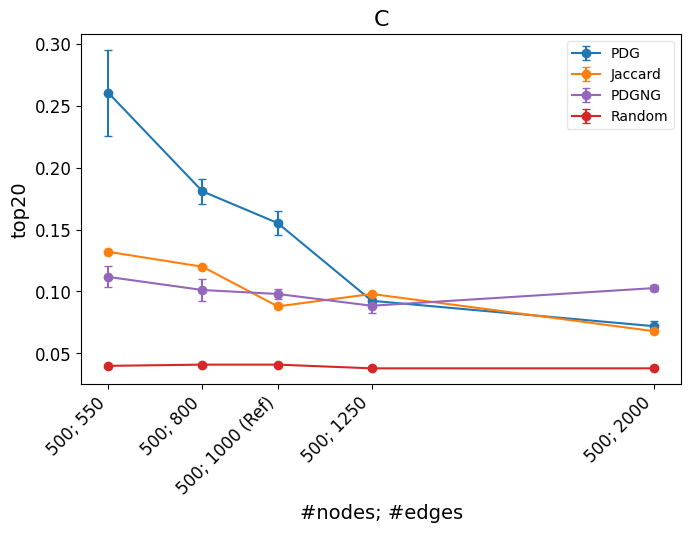

In [63]:
def line_plot_metric(exp: str, metric: str, title: str = None, normalize: bool = False, preferred_model_types=None, strict: bool = True):
    """Plot a line chart with one line per model type for a given experiment."""
    dfs_info = load_variant_dfs(exp, strict=strict)
    if not dfs_info:
        raise ValueError(f"No variants found for experiment '{exp}'")

    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    if not available_variants:
        raise ValueError(f"No data found for metric '{metric}' in experiment '{exp}'")

    num_pattern = re.compile(r"\d+")
    suffix_nums = []
    max_len = 0
    for v in available_variants:
        suffix = v[len(exp) + 1:] if v.startswith(exp + '_') else v
        nums = [int(x) for x in num_pattern.findall(suffix)]
        suffix_nums.append(nums)
        max_len = max(max_len, len(nums))

    best_idx = None
    best_unique = -1
    for idx in range(max_len):
        vals = [nums[idx] if idx < len(nums) else None for nums in suffix_nums]
        unique_vals = len(set(v for v in vals if v is not None))
        if unique_vals > best_unique:
            best_unique = unique_vals
            best_idx = idx

    if best_idx is None or best_unique <= 1:
        raise ValueError(f"Cannot determine varying numeric component for experiment '{exp}'. Tokens: {suffix_nums}")

    x_vals = [nums[best_idx] if best_idx < len(nums) else float('nan') for nums in suffix_nums]

    model_types = select_model_types(model_types_set, preferred=preferred_model_types)

    model_names = {
        "overlap": "Jaccard",
        "random": "Random",
        "pdgrapher": "PDG",
        "pdgraphernognn": "PDGNG"
    }

    fig, ax = create_fixed_axes()

    any_plotted = False
    for j, mt in enumerate(model_types):
        pts = []
        for i, v in enumerate(available_variants):
            x = x_vals[i]
            y = means_list[i].get(mt, float('nan'))
            yerr = stds_list[i].get(mt, float('nan')) if stds_list[i] is not None else float('nan')
            if pd.isna(x) or pd.isna(y):
                continue
            pts.append((float(x), float(y), float(yerr) if not pd.isna(yerr) else float('nan')))

        if not pts:
            msg = f"No data for model_type '{mt}' in experiment '{exp}'."
            if strict:
                raise ValueError(msg)
            print("Warning:", msg, "Skipping.")
            continue

        pts.sort(key=lambda t: t[0])
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        errs = [p[2] for p in pts]

        ax.errorbar(
            xs, ys, yerr=errs,
            marker='o',
            label=model_names.get(mt, mt),
            color=get_model_color(mt),
            capsize=3
        )

        any_plotted = True

    if not any_plotted:
        raise ValueError(f"No plotted data for experiment '{exp}' and metric '{metric}'.")

    uniq_xs = sorted(set(x for x in x_vals if not pd.isna(x)))
    if uniq_xs:
        ax.set_xticks(uniq_xs)
        xtick_labels = [f"500; {str(int(x))} (Ref)"  if x == 1000 else f"500; {str(int(x))}" for x in uniq_xs]
        #xtick_labels = [f"{str(int(x))}/{str(int(x*2))} (Ref)"  if x == 500 else f"{str(int(x))}/{str(int(x*2))}" for x in uniq_xs]
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=12)
        ax.tick_params(axis='y', labelsize=12)

    ax.set_xlabel('#nodes; #edges', fontsize=14)
    ax.set_ylabel(("norm " if normalize else "") + metric_labels.get(metric, metric), fontsize=14)
    ax.set_title(title if title is not None else f"{exp}: {metric}", fontsize=16)
    ax.legend(loc='best', framealpha=0.5)

    fig.tight_layout()
    plt.show()


# # Example (uncomment to run):
line_plot_metric('exp3', 'source in top 20', title='C')
# line_plot_metric('exp3', 'accuracy', title='Different Densities of the Underlying Ground-Truth Graph')
# line_plot_metric('exp3', 'avg rank of source', normalize=True, title='Different Densities of the underlying Ground-Truth Graph')
# line_plot_metric('exp4', 'source in top 20', title='Different Sizes of the underlying Ground-Truth Graph')
# line_plot_metric('exp4', 'accuracy', title='Different Sizes of the underlying Ground-Truth Graph')
# line_plot_metric('exp4', 'avg rank of source', normalize=True)


0.14816666666666667
0.088
0.098
0.041


/tmp/ipykernel_2402813/59730910.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


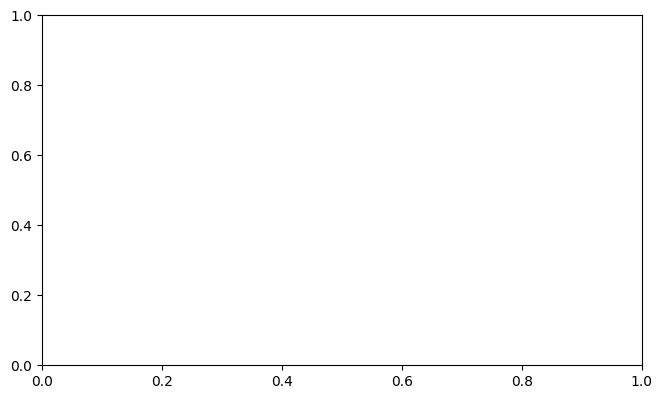

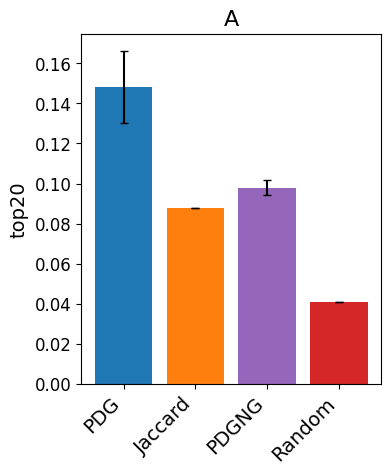

Displayed plot for ref: metric='source in top 20' (normalize=False)
0.24168033333333336
0.278198
0.26604039999999995
0.48638600000000004


/tmp/ipykernel_2402813/59730910.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


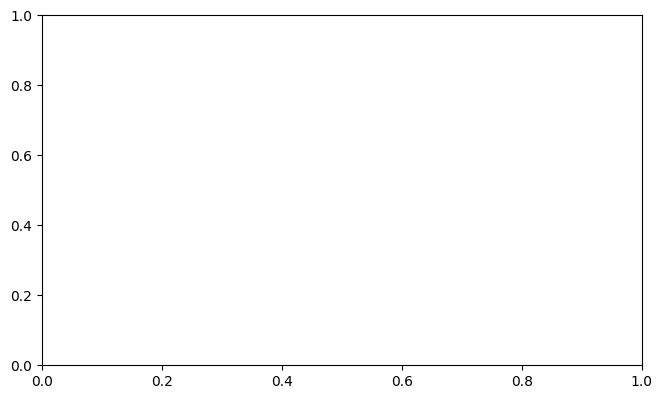

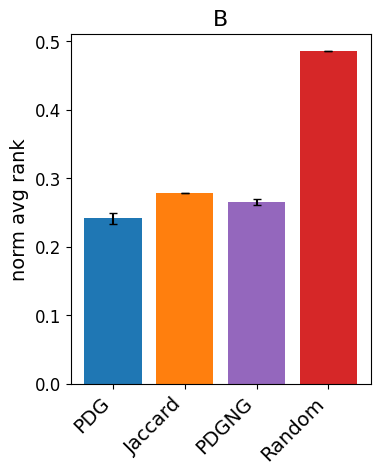

Displayed plot for ref: metric='avg rank of source' (normalize=True)
0.014166666666666668
0.007
0.005600000000000001
0.001


/tmp/ipykernel_2402813/59730910.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


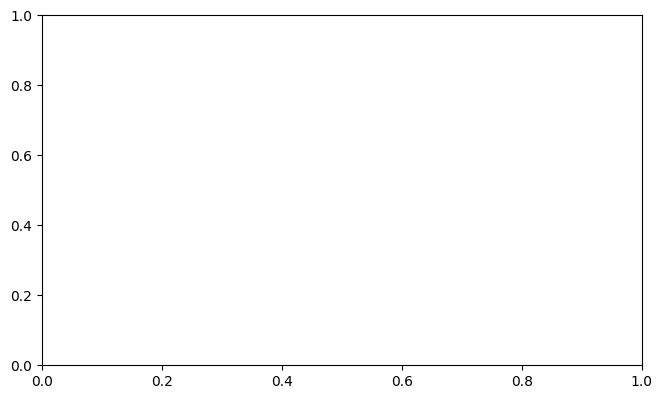

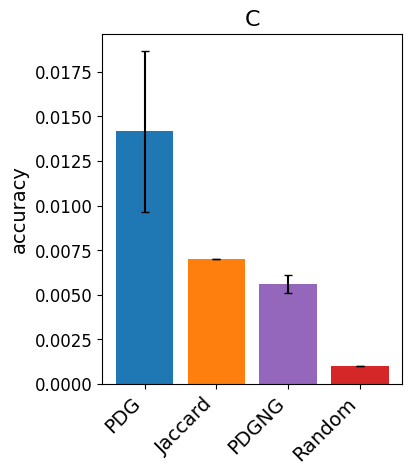

Displayed plot for ref: metric='accuracy' (normalize=False)


In [40]:
plot_metric("ref", "source in top 20", strict=False, title="A", collapse_pdgraphernognn=False, no_legend=True)
plot_metric("ref", "avg rank of source", strict=False, normalize=True,title="B", collapse_pdgraphernognn=False, no_legend=True)
plot_metric("ref", "accuracy", strict=False, title="C", collapse_pdgraphernognn=False, no_legend=True)


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


0.166
0.34933333333333333
0.396
0.484
0.11499999999999999
0.38079999999999997
0.036
0.037


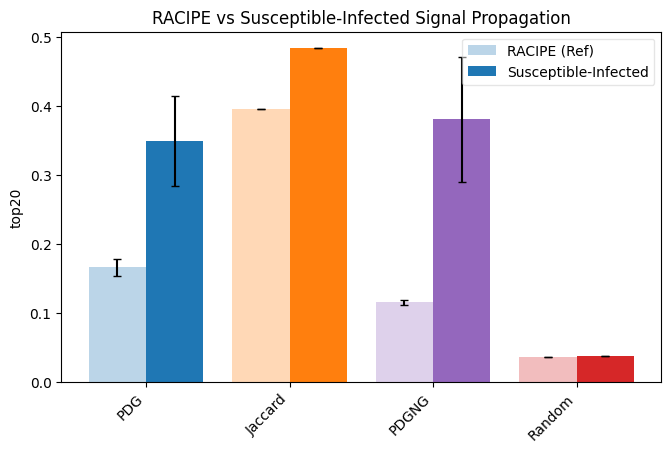

Displayed plot for expsi: metric='source in top 20' (normalize=False)
0.2380392
0.14101533333333335
0.12978399999999998
0.07563800000000001
0.262309
0.1212304
0.504074
0.498782


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


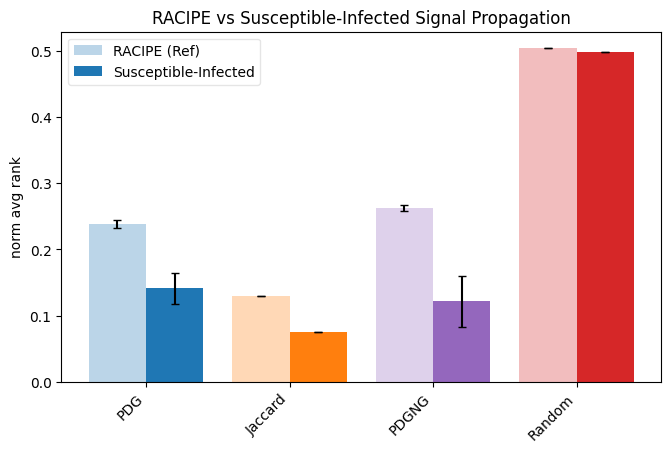

Displayed plot for expsi: metric='avg rank of source' (normalize=True)
0.3041545643153527
0.510844398340249
0.2909903181189488
0.49652904564315353


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


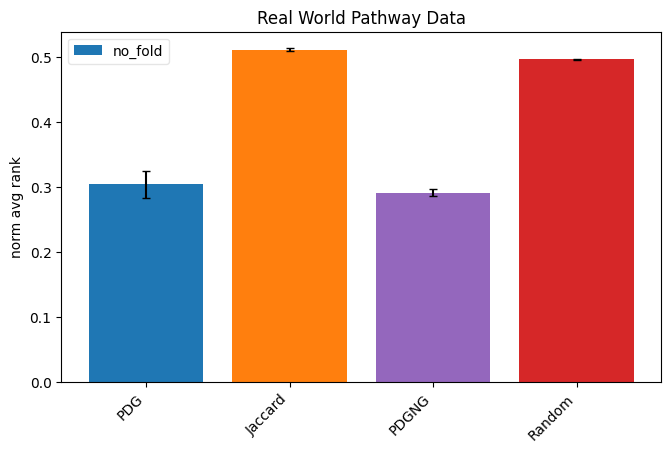

Displayed plot for pathway: metric='avg rank of source' (normalize=True)
0.31625000000000003
0.0745
0.314
0.08349999999999999


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


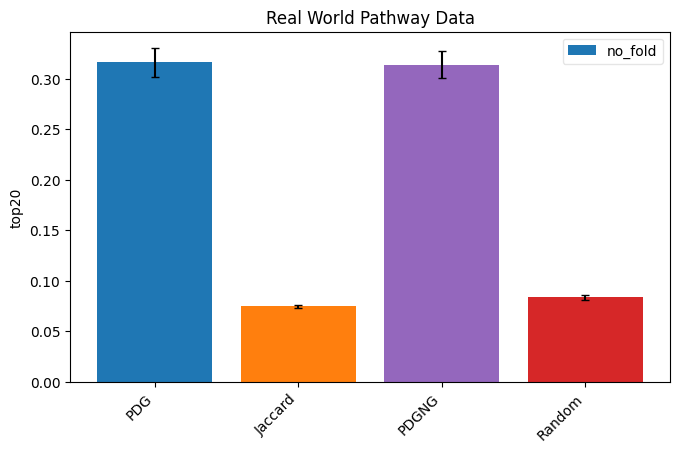

Displayed plot for pathway: metric='source in top 20' (normalize=False)
0.06125
0.0035
0.078
0.0045000000000000005


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


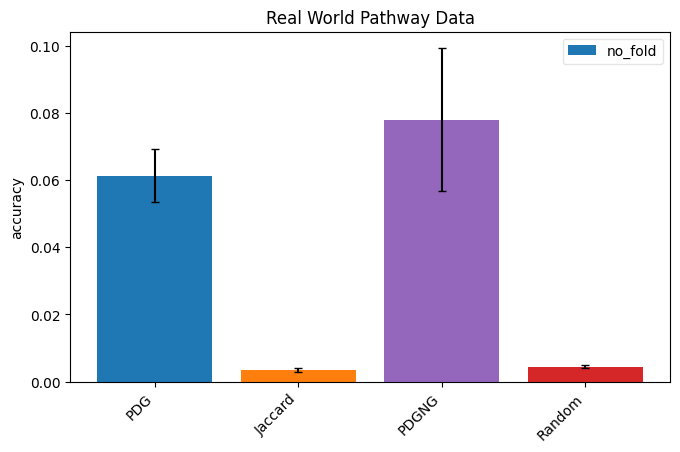

Displayed plot for pathway: metric='accuracy' (normalize=False)


In [27]:
plot_metric("expsi", "source in top 20", strict=False, title="RACIPE vs Susceptible-Infected Signal Propagation", collapse_pdgraphernognn=False)
plot_metric("expsi", "avg rank of source", normalize=True, strict=False, title="RACIPE vs Susceptible-Infected Signal Propagation", collapse_pdgraphernognn=False)
plot_metric("pathway", "avg rank of source", normalize=True, strict=False, title="Real World Pathway Data", collapse_pdgraphernognn=False)
plot_metric("pathway", "source in top 20", normalize=False, strict=False, title="Real World Pathway Data", collapse_pdgraphernognn=False)
plot_metric("pathway", "accuracy", normalize=False, strict=False, title="Real World Pathway Data", collapse_pdgraphernognn=False)

/tmp/ipykernel_2402813/3062171637.py:637: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


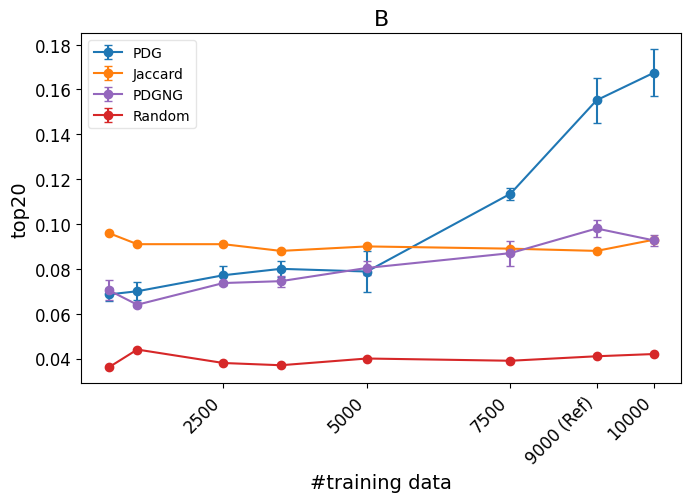

/tmp/ipykernel_2402813/3062171637.py:487: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Displayed sample size plot for metric='source in top 20' (normalize=False)
baseline avg: 0.09632708333333333
[np.float64(0.1552), np.float64(0.11339999999999999), np.float64(0.10700000000000001), np.float64(0.097), np.float64(0.10259999999999998), np.float64(0.0986), np.float64(0.096), np.float64(0.086)]


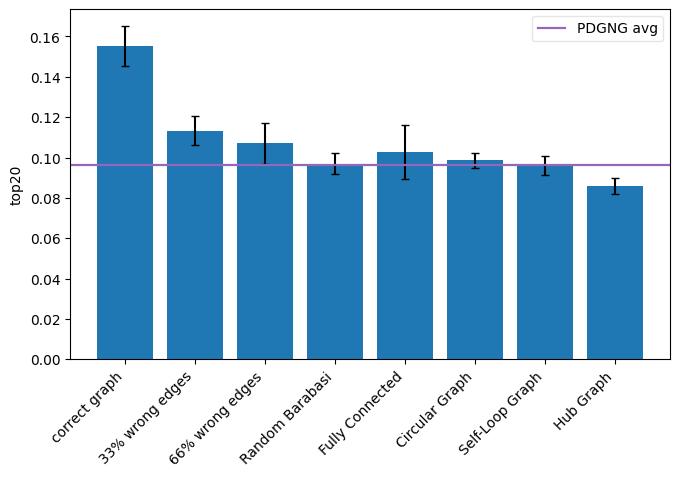

Displayed pdgrapher - pdgraphernognn difference plot for exp2: metric='source in top 20' (normalize=False)


/tmp/ipykernel_2402813/3062171637.py:487: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


baseline avg: 0.005864583333333334
[np.float64(0.016), np.float64(0.0116), np.float64(0.0078), np.float64(0.0064), np.float64(0.005600000000000001), np.float64(0.0062), np.float64(0.0068000000000000005), np.float64(0.0058000000000000005)]


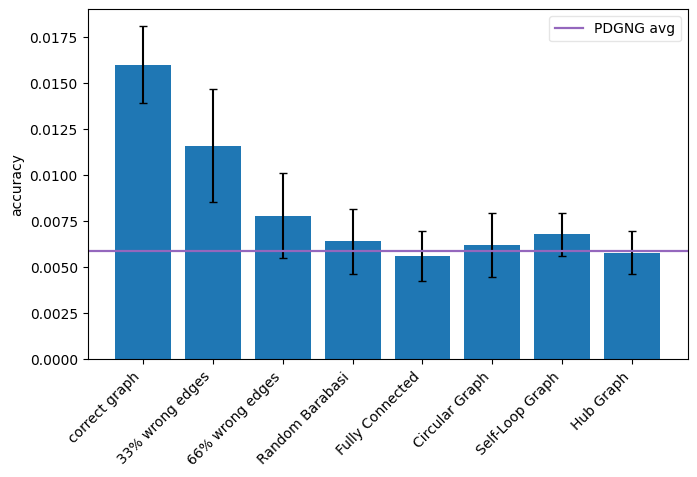

Displayed pdgrapher - pdgraphernognn difference plot for exp2: metric='accuracy' (normalize=False)
baseline avg: 0.2652313708333333
[np.float64(0.2380856), np.float64(0.24996959999999996), np.float64(0.257316), np.float64(0.26461959999999995), np.float64(0.24876319999999996), np.float64(0.2634964), np.float64(0.2648136), np.float64(0.27217240000000004)]


/tmp/ipykernel_2402813/3062171637.py:487: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


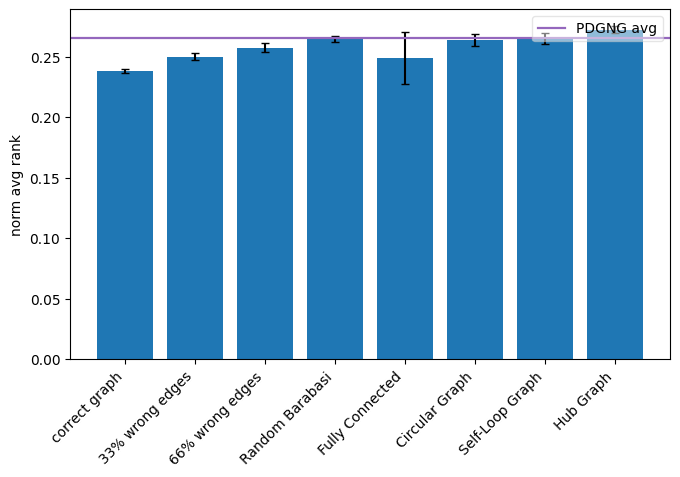

Displayed pdgrapher - pdgraphernognn difference plot for exp2: metric='avg rank of source' (normalize=True)


In [65]:
sample_size_bars('source in top 20', normalize=False)
# sample_size_bars('accuracy', normalize=False)
# sample_size_bars('avg rank of source', normalize=True)
plot_pdgrapher_with_nognn_hline('exp2', 'source in top 20', normalize=False, strict=False, title="PDG Top20-Score for Different Graph Priors")
plot_pdgrapher_with_nognn_hline('exp2', 'accuracy', normalize=False, strict=False, title="PDG Top20-Score for Different Graph Priors")
plot_pdgrapher_with_nognn_hline('exp2', 'avg rank of source', normalize=True, strict=False, title="PDG Top20-Score for Different Graph Priors")

In [29]:
exp = "exp1"
metric = "source in top 20"
normalize = False


dfs_info = load_variant_dfs(exp)
available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
means_list

[advanced_random     0.070000
 overlap             0.088000
 pdgrapher           0.148167
 pdgraphernognn      0.098000
 random              0.041000
 smallestSuperset    0.040000
 dtype: float64,
 advanced_random     0.0700
 overlap             0.0950
 pdgrapher           0.1134
 pdgraphernognn      0.0926
 random              0.0410
 smallestSuperset    0.0400
 dtype: float64,
 advanced_random     0.0720
 overlap             0.0870
 pdgrapher           0.1070
 pdgraphernognn      0.0968
 random              0.0410
 smallestSuperset    0.0400
 dtype: float64,
 advanced_random     0.04100
 overlap             0.04000
 pdgrapher           0.09700
 pdgraphernognn      0.09275
 random              0.04100
 smallestSuperset    0.04000
 dtype: float64]

0.14816666666666667
0.11339999999999999
0.10700000000000001
0.097
0.088
0.095
0.087
0.04
0.0950375
0.041


/tmp/ipykernel_2402813/3062171637.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


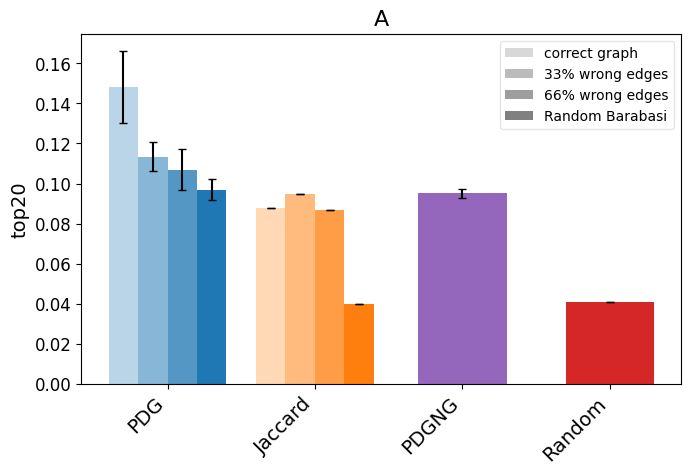

Displayed plot for exp1: metric='source in top 20' (normalize=False)
0.2380856


/tmp/ipykernel_2402813/3062171637.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


0.24996959999999996
0.257316
0.26461959999999995
0.24876319999999996
0.2634964
0.2648136
0.27217240000000004
0.278198
0.302346
0.29952
0.506204
0.506204
0.506204
0.501088
0.50552
0.2652313708333333
0.4863860000000001


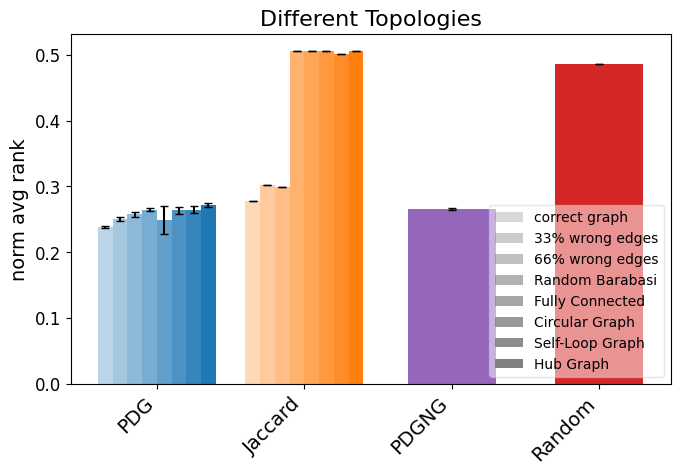

Displayed plot for exp2: metric='avg rank of source' (normalize=True)
0.32850999999999997
0.332044
0.2380856
0.20146333333333333
0.33744
0.36380399999999996
0.278198
0.23493333333333336
0.3445325
0.349056
0.26604039999999995
0.20522916666666666
0.48582
0.49445999999999996
0.48638600000000004
0.499195


/tmp/ipykernel_2402813/3062171637.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


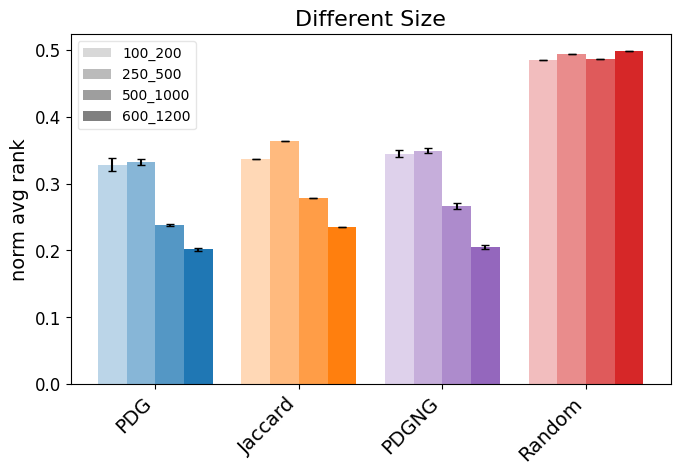

Displayed plot for exp4: metric='avg rank of source' (normalize=True)
0.3897474285714286
0.36576257142857144
0.2859317142857143
0.2819205
0.27692440000000007
0.2626825
0.2380856
0.2391215
0.276362
0.28001
0.282986
0.28282799999999997
0.280964
0.28043599999999996
0.278198
0.27941000000000005
0.40072399999999997
0.366953
0.2876493333333333
0.28009399999999995
0.28186920000000004
0.269046
0.26604039999999995
0.26569333333333334
0.501252
0.500062
0.5039239999999999
0.502958
0.4972200000000001
0.498114
0.48638600000000004
0.5024580000000001


/tmp/ipykernel_2402813/3062171637.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


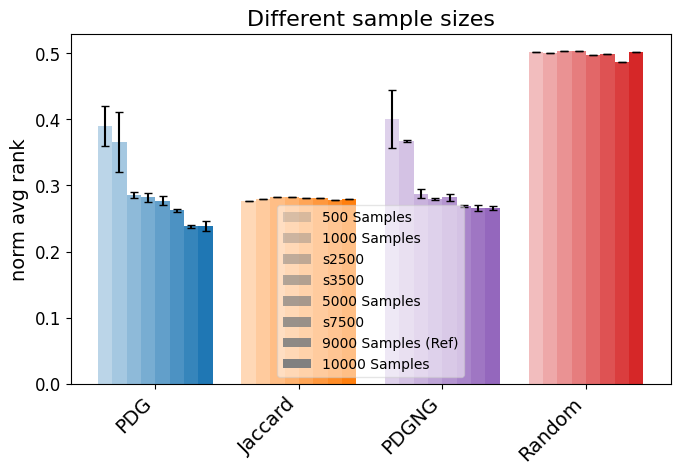

Displayed plot for exp5: metric='avg rank of source' (normalize=True)


In [66]:
# Example usages:
# plot_metric("exp1", "avg rank of source", normalize=True, strict=False, title="Increasingly wrong Graph Prior")
# plot_metric("exp1", "accuracy", normalize=False, strict=False, title="Increasingly wrong Graph Prior")
plot_metric("exp1", "source in top 20", normalize=False, strict=False, title="A")
plot_metric("exp2", "avg rank of source", normalize=True, strict=False, title="Different Topologies")
# plot_metric("exp3", "avg rank of source", normalize=True, strict=False, title="Different Connectivities")
plot_metric("exp4", "avg rank of source", normalize=True, strict=False, title="Different Size",collapse_pdgraphernognn=False)
plot_metric("exp5", "avg rank of source", normalize=True, strict=False, title="Different sample sizes", collapse_pdgraphernognn=False)

0.166
0.34933333333333333
0.396
0.484
0.11499999999999999
0.38079999999999997
0.036
0.037


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


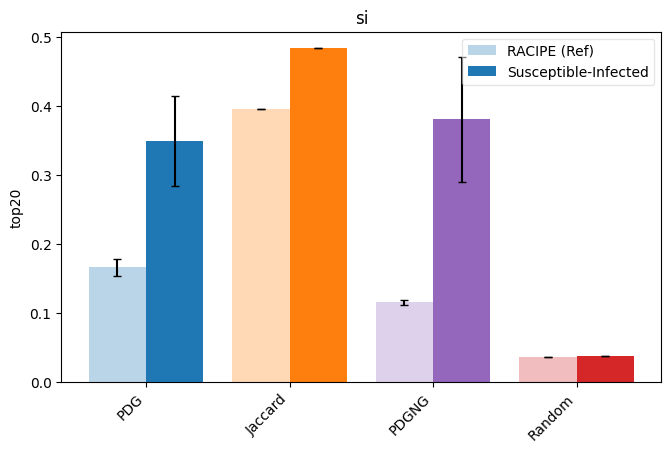

Displayed plot for expsi: metric='source in top 20' (normalize=False)
0.166
0.1552
0.396
0.08799999999999998
0.11499999999999999
0.098
0.036
0.041


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


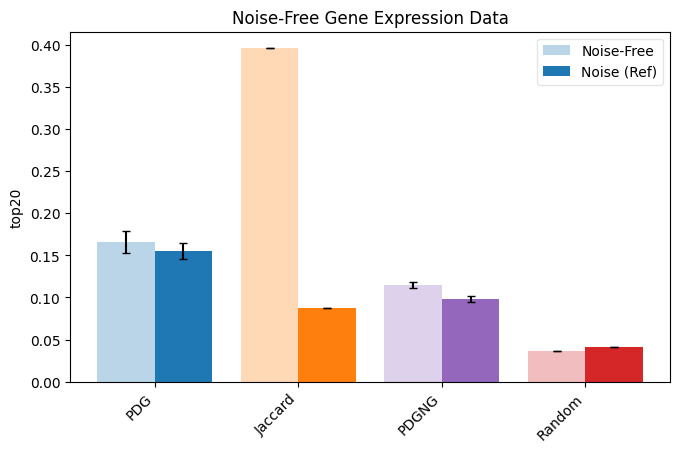

Displayed plot for exp0: metric='source in top 20' (normalize=False)
0.020999999999999998
0.016
0.10900000000000001
0.007
0.006999999999999999
0.005600000000000001
0.001
0.001


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


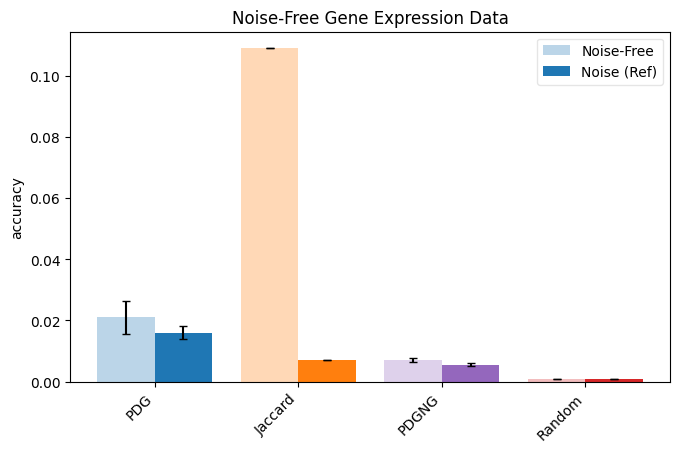

Displayed plot for exp0: metric='accuracy' (normalize=False)
0.2380392
0.2380856
0.12978399999999998
0.278198
0.262309
0.26604039999999995
0.504074
0.48638600000000004


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


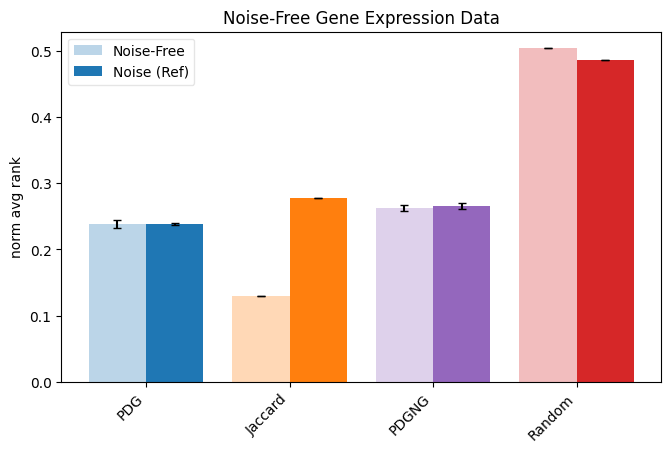

Displayed plot for exp0: metric='avg rank of source' (normalize=True)
0.14816666666666667
0.11339999999999999
0.10700000000000001
0.097
0.088
0.095


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


0.087
0.04
0.0950375
0.041


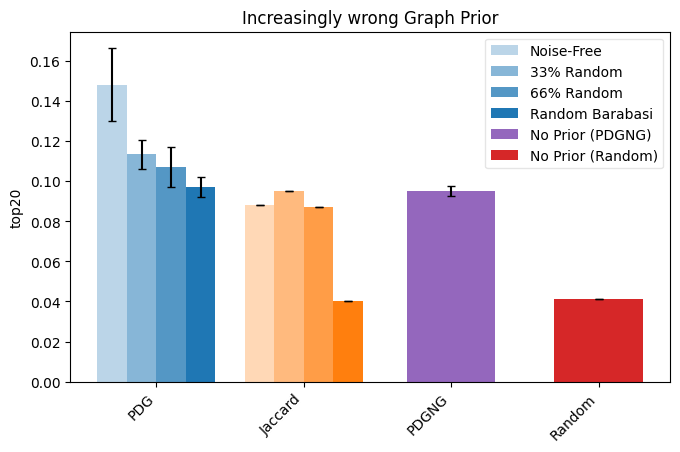

Displayed plot for exp1: metric='source in top 20' (normalize=False)
0.1552
0.11339999999999999
0.10700000000000001
0.097
0.10259999999999998
0.0986
0.096
0.086
0.08799999999999998
0.095
0.087
0.04
0.04
0.04
0.028000000000000004
0.026000000000000002
0.09632708333333333
0.041


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


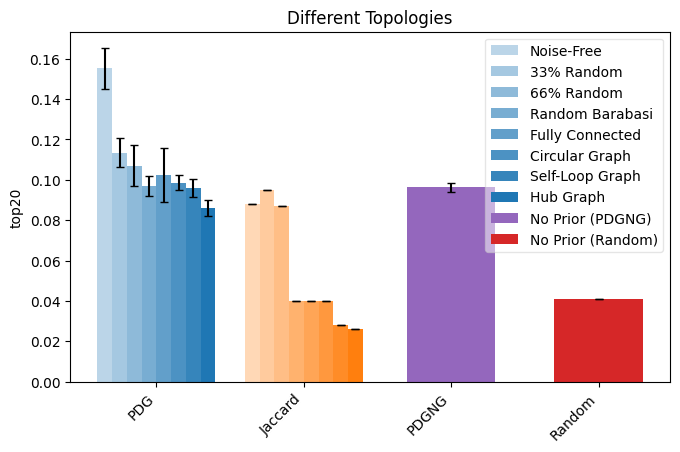

Displayed plot for exp2: metric='source in top 20' (normalize=False)
0.26020000000000004
0.1808
0.1552
0.0925
0.07200000000000001
0.132
0.12
0.08799999999999998
0.098
0.068
0.11175
0.1012
0.098
0.0885
0.10275
0.04
0.041
0.041
0.038
0.038


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


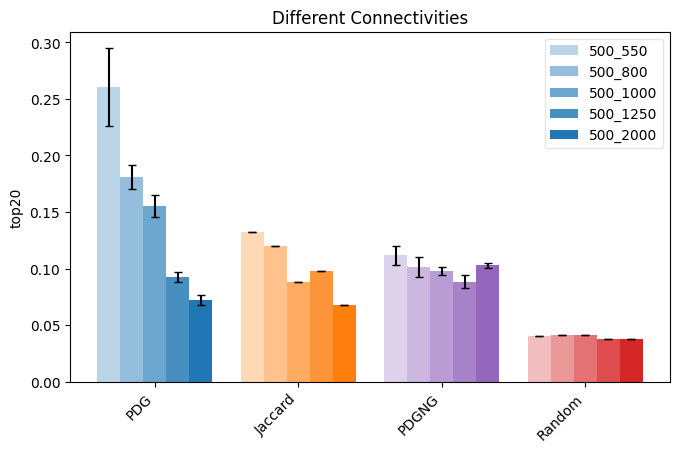

Displayed plot for exp3: metric='source in top 20' (normalize=False)


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


0.3328
0.2095
0.1552
0.1315
0.286
0.141
0.08799999999999998
0.098
0.30175
0.15633333333333332
0.098
0.11149999999999999
0.215
0.09000000000000001
0.041
0.032


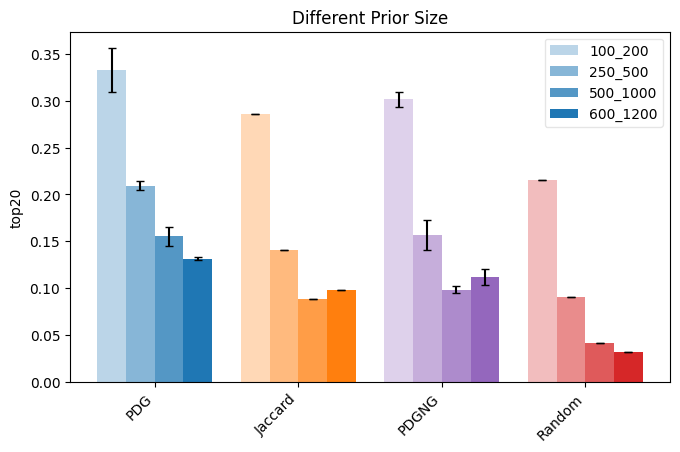

Displayed plot for exp4: metric='source in top 20' (normalize=False)
0.06857142857142857
0.07
0.07714285714285715
0.08
0.07880000000000001
0.1135
0.1552
0.16749999999999998
0.096
0.091
0.09100000000000001
0.088
0.09
0.089
0.08799999999999998
0.09300000000000001
0.07050000000000001
0.064
0.07366666666666666
0.0745
0.0804
0.087
0.098
0.09266666666666667
0.036
0.044
0.038
0.037
0.04
0.039
0.041
0.042


/tmp/ipykernel_2402813/2351320206.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


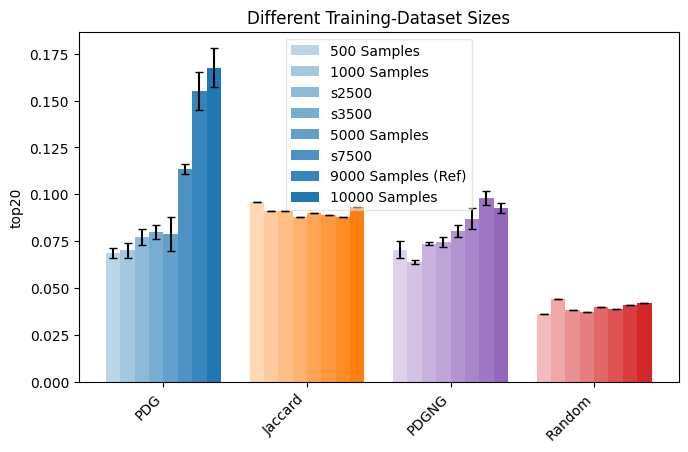

Displayed plot for exp5: metric='source in top 20' (normalize=False)


In [31]:
# Example usages:
plot_metric("expsi", "source in top 20", strict=False, title="si", collapse_pdgraphernognn=False)
plot_metric("exp0", "source in top 20", strict=False, title="Noise-Free Gene Expression Data", collapse_pdgraphernognn=False)
plot_metric("exp0", "accuracy", strict=False, title="Noise-Free Gene Expression Data", collapse_pdgraphernognn=False)
plot_metric("exp0", "avg rank of source", normalize=True, strict=False, title="Noise-Free Gene Expression Data", collapse_pdgraphernognn=False)
plot_metric("exp1", "source in top 20", strict=False, title="Increasingly wrong Graph Prior")
plot_metric("exp2", "source in top 20", strict=False, title="Different Topologies")
plot_metric("exp3", "source in top 20", strict=False, title="Different Connectivities", collapse_pdgraphernognn=False)
plot_metric("exp4", "source in top 20", strict=False, title="Different Prior Size", collapse_pdgraphernognn=False)
plot_metric("exp5", "source in top 20", strict=False, title="Different Training-Dataset Sizes", collapse_pdgraphernognn=False)

# plot_metric("exp4", "source in top 20", strict=False, title="Different Size")
# plot_metric("exp5", "source in top 20", strict=False, title="Different sample sizes")

In [32]:
# plot_model_variants_against_baseline("exp2", "avg rank of source", model_type="pdgrapher", baseline="pdgraphernognn", normalize=True, title="Effect of different topologies on PDGrapher")
# plot_model_variants_against_baseline("exp2", "source in top 20", model_type="pdgrapher", baseline="pdgraphernognn", normalize=True, title="Effect of different topologies on PDGrapher")
# plot_model_variants_against_baseline("exp3", "source in top 20", model_type="pdgrapher", baseline="pdgraphernognn", normalize=True, title="Effect of different topologies on PDGrapher")

/tmp/ipykernel_2402813/2351320206.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


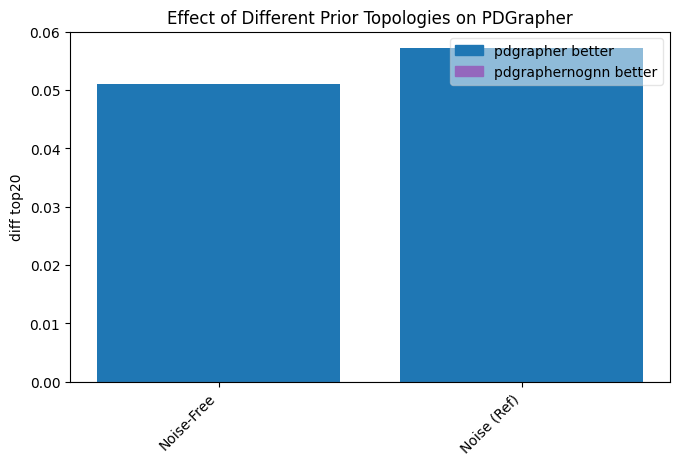

/tmp/ipykernel_2402813/2351320206.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


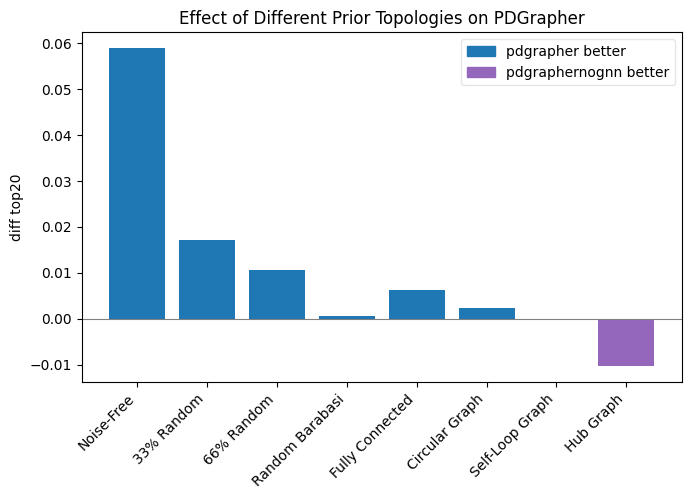

/tmp/ipykernel_2402813/2351320206.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


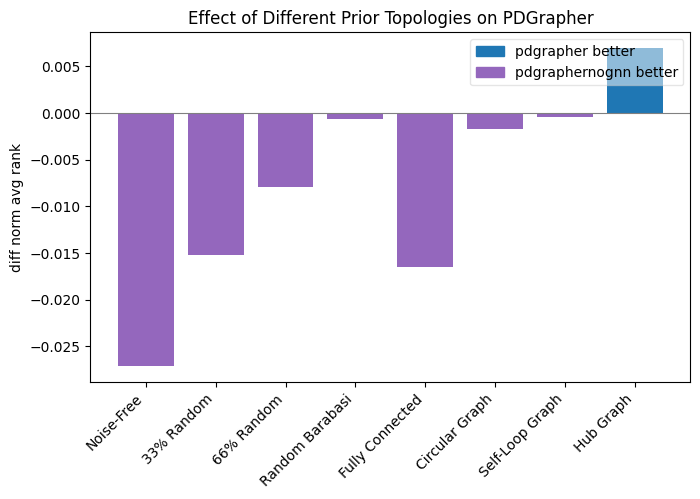

/tmp/ipykernel_2402813/2351320206.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


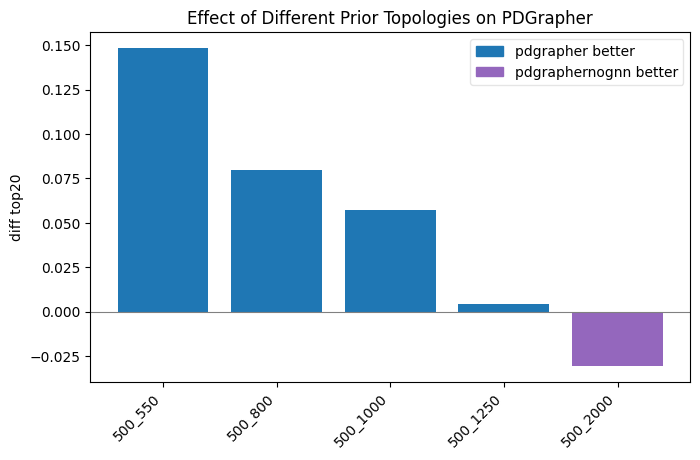

/tmp/ipykernel_2402813/2351320206.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


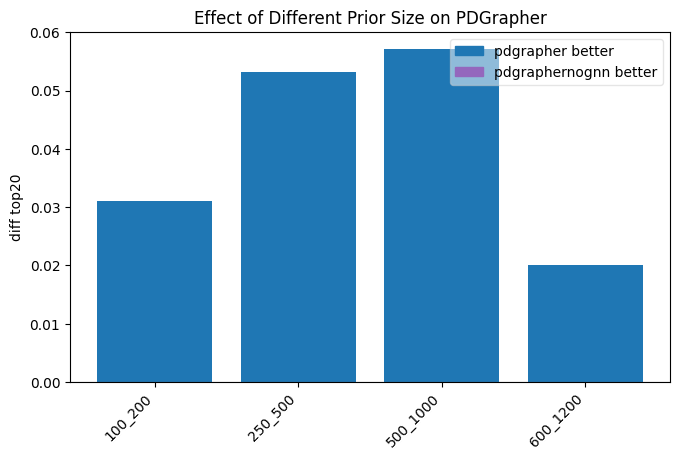

/tmp/ipykernel_2402813/2351320206.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


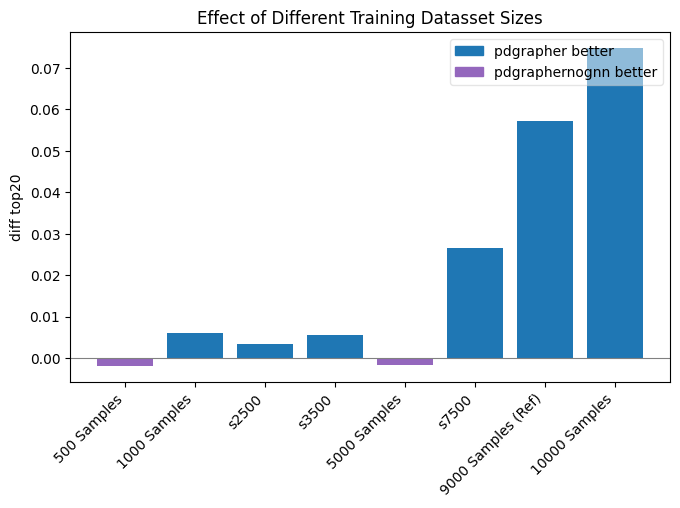

In [33]:

# Example of difference-plot for a single experiment (change strict to True to enforce presence)
# plot_model_difference("exp2", "avg rank of source", "pdgrapher", "pdgraphernognn", normalize=True, strict=False, title = "Effect of different topologies on PDGrapher")
plot_model_difference("exp0", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Topologies on PDGrapher", summarize_baseline=False)
plot_model_difference("exp2", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Topologies on PDGrapher", summarize_baseline=True)
plot_model_difference("exp2", "avg rank of source", "pdgrapher", "pdgraphernognn", normalize=True, strict=False, title = "Effect of Different Prior Topologies on PDGrapher", summarize_baseline=True)
plot_model_difference("exp3", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Topologies on PDGrapher", summarize_baseline=False)
plot_model_difference("exp4", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Size on PDGrapher", summarize_baseline=False)
plot_model_difference("exp5", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Training Datasset Sizes", summarize_baseline=False)

/tmp/ipykernel_2402813/2351320206.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


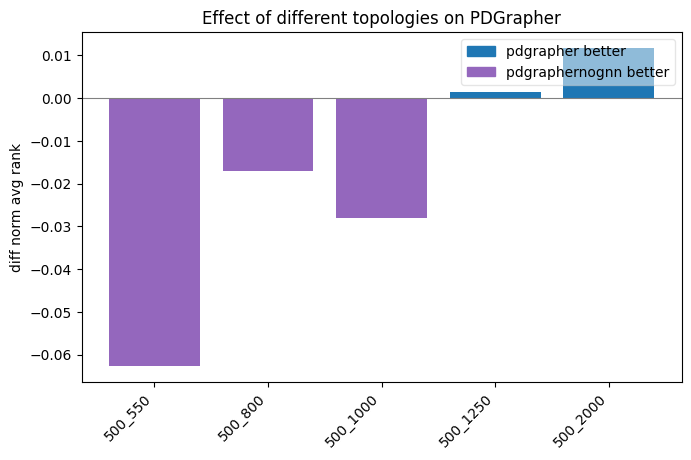

/tmp/ipykernel_2402813/2351320206.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


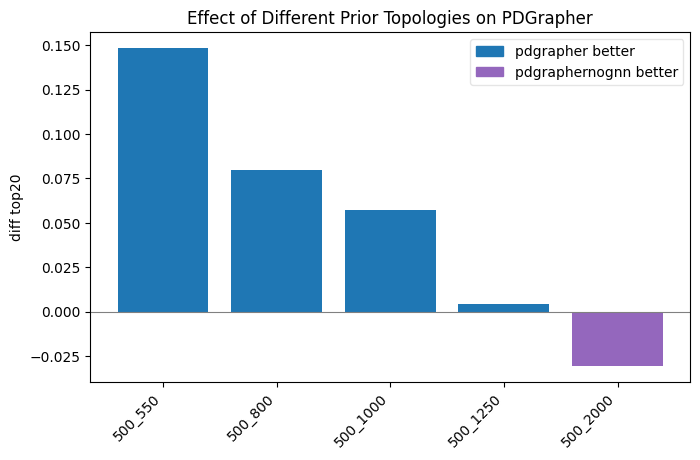

In [34]:
plot_model_difference("exp3", "avg rank of source", "pdgrapher", "pdgraphernognn", normalize=True, strict=False, title = "Effect of different topologies on PDGrapher")
plot_model_difference("exp3", "source in top 20", "pdgrapher", "pdgraphernognn", strict=False, title = "Effect of Different Prior Topologies on PDGrapher")

/tmp/ipykernel_2402813/2351320206.py:412: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


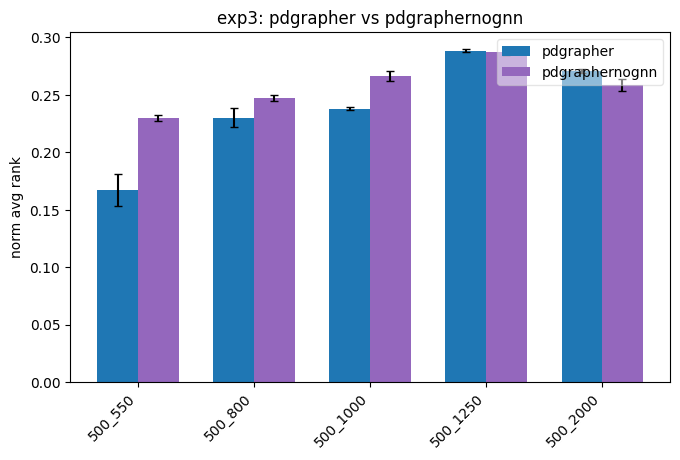

[np.float64(-0.06270149999999997), np.float64(-0.01701120000000006), np.float64(-0.027954799999999946), np.float64(0.0013499999999999623), np.float64(0.01171950000000005)]


NameError: name 'palette' is not defined

In [35]:
plot_pdgrapher_vs_nognn_grouped("exp3", "avg rank of source", True)
plot_pdgrapher_vs_nognn_difference("exp3", "avg rank of source", True)

plot_pdgrapher_vs_nognn_grouped("exp4", "avg rank of source", True)
plot_pdgrapher_vs_nognn_difference("exp4", "avg rank of source", True)

plot_pdgrapher_vs_nognn_grouped("exp5", "avg rank of source", True)
plot_pdgrapher_vs_nognn_difference("exp5", "avg rank of source", True)

In [ ]:
def og_pdgrapher_data(folder_prefix, metric, normalize=False, title=None, pdg_metric: bool = False):
    """Plot results of experiments on og pdgrapher datasets, sorted by mean (desc)."""
    variant_folders = [f for f in os.listdir() if f.startswith(folder_prefix) and os.path.isdir(f)]
    if not variant_folders:
        raise ValueError(f"No folders found with prefix '{folder_prefix}'")
    ideal_order = ['pdgrapher_grn', 'pdgrapher_nognn', 'pdgrapher_dense', 'pdgrapher_hub']
    # remove whatever is not in ideal_order
    variant_folders = [f for f in variant_folders if f in ideal_order]
    variant_folders.sort(key=lambda f: ideal_order.index(f) if f in ideal_order else len(ideal_order))

    import json

    num_nodes = 10716  # og pdgrapher graph size
    rows = []
    for f in variant_folders:
        result_files = [rf for rf in os.listdir(f) if rf.endswith(".json")]
        if not result_files:
            raise FileNotFoundError(f"No .json result files found in folder '{f}'")
    

        metrics = []
        for rf in result_files:
            path = os.path.join(f, rf)
            with open(path, "r") as infile:
                data = json.load(infile)
                # metric is expected under data["metrics"][metric]
                if "metrics" not in data or not isinstance(data["metrics"], dict):
                    raise ValueError(f"File '{path}' missing 'metrics' dict")
                if pdg_metric:
                    val = data["metrics"]['pdgrapher_perturbation_discovery'].get(metric)
                else:
                    val = data["metrics"].get(metric)
                if val is None:
                    continue
                try:
                    val = float(val)
                except Exception:
                    raise ValueError(f"Non-numeric metric value for '{metric}' in file '{path}': {val}")
                if normalize:
                    val = val / float(num_nodes)
                metrics.append(val)

        if not metrics:
            raise ValueError(f"No metric '{metric}' values found in any .json within folder '{f}'")
        s = pd.Series(metrics)
        rows.append({"folder": f, "mean": float(s.mean()), "std": float(s.std(ddof=0))})

    # sort by mean descending
    #rows.sort(key=lambda r: r["mean"], reverse=True)

    bar_labels = {
        "nognn": "PDGNG",
        "grn": "PDG (PPI-Prior)",
        "dense": "PDG (Circular)",
        "hub": "PDG (Hub)",
    }

    bar_colors = {
        "nognn": get_model_color("pdgraphernognn"),
        "grn": get_model_color("pdgrapher"),
        "dense": get_model_color("pdgrapher"),
        "hub": get_model_color("pdgrapher"),
    }

    x = list(range(len(rows)))
    fig, ax = create_fixed_axes()
    palette = sns.color_palette("colorblind")
    for i, r in enumerate(rows):
        name = r["folder"].replace(folder_prefix + "_", "")
        label = bar_labels.get(name, r["folder"])
        print(f"{label}: mean={r['mean']}, std={r['std']}")
        ax.bar(x[i], r["mean"], width=0.6, yerr=r["std"], color=bar_colors.get(name, palette[i % len(palette)]), label=label, capsize=3)

    ax.set_title(title if title is not None else folder_prefix)
    ax.set_xticks(x)
    ax.set_xticklabels([bar_labels.get(r["folder"].replace(folder_prefix + "_", ""), r["folder"]) for r in rows], rotation=45, ha="right")
    ax.set_ylabel(("norm " if normalize else "") + metric_labels.get(metric, metric))
    fig.tight_layout()
    plt.show()
    print(f"Displayed og pdgrapher data plot for '{folder_prefix}': metric='{metric}' (normalize={normalize})")

def sample_size_bars(metric: str, normalize: bool = False, eqd_suffix: str = '_eqd', pdg_metric: bool = False):
    # For this experiment 'exp5': ['exp5_s2500_eqd', 'exp5_s5000_eqd', 'exp5_s7500_eqd', 'exp5_s10000_eqd']
    # Plot sample size (from folder name) vs performance for pdgrapher and pdgraphernognn
    # Additionally plot pdgrapher values for variants ending with `eqd_suffix` as a separate colored line.
    exp = 'exp5'
    dfs_info = load_variant_dfs(exp, strict=True)

    pdg = {}       # pdgrapher (non-eqd)
    pdg_eqd = {}   # pdgrapher for eqd variants
    pdn = {}       # pdgraphernognn

    for v, df, num_nodes in dfs_info:
        m = re.search(r's(\d+)', v)
        if not m:
            print(f"Warning: cannot extract sample size from variant '{v}'. Skipping.")
            continue
        size = int(m.group(1))
        means = {}
        for mt, group in df.groupby("model_type"):
            metrics = []
            for r in group.to_dict(orient="records"):
                val = extract_metric(r, metric, pdg_metric=pdg_metric)
                if val is None:
                    continue
                if normalize:
                    if num_nodes is None:
                        raise ValueError(f"Cannot normalize variant '{v}' by num_nodes: num_nodes missing.")
                    val = float(val) / float(num_nodes)
                metrics.append(float(val))
            if metrics:
                s = pd.Series(metrics)
                means[mt] = s.mean()

        # assign to proper dict
        if 'pdgrapher' in means:
            if v.endswith(eqd_suffix):
                pdg_eqd[size] = means['pdgrapher']
            else:
                pdg[size] = means['pdgrapher']
        if 'pdgraphernognn' in means:
            pdn[size] = means['pdgraphernognn']

    # union all sizes and sort
    all_sizes = sorted(set(list(pdg.keys()) + list(pdg_eqd.keys()) + list(pdn.keys())))
    if not all_sizes:
        raise ValueError(f"No sample-size data found for experiment '{exp}' and metric '{metric}'.")

    # aligned value lists (NaN for missing)
    import math
    pdg_vals = [pdg.get(s, float('nan')) for s in all_sizes]
    pdg_eqd_vals = [pdg_eqd.get(s, float('nan')) for s in all_sizes]
    pdn_vals = [pdn.get(s, float('nan')) for s in all_sizes]

    fig, ax = create_fixed_axes()

    # Use consistent colors
    ax.plot(all_sizes, pdg_vals, marker='o', label='pdgrapher', color=get_model_color('pdgrapher'))
    if any(not math.isnan(v) for v in pdg_eqd_vals):
        sizes_eqd = [s for s, v in zip(all_sizes, pdg_eqd_vals) if not math.isnan(v)]
        vals_eqd = [v for v in pdg_eqd_vals if not math.isnan(v)]
        ax.plot(sizes_eqd, vals_eqd, marker='o', label='pdgrapher_eqd', color=get_model_color('pdgrapher_eqd'))
    ax.plot(all_sizes, pdn_vals, marker='o', label='pdgraphernognn', color=get_model_color('pdgraphernognn'))

    ax.set_xlabel('Sample Size')
    ax.set_ylabel(metric)
    ax.set_title(f"{exp}: Sample Size vs {metric}")
    ax.legend()
    fig.tight_layout()
    plt.show()
    print(f"Displayed sample size plot for {exp}: metric='{metric}' (normalize={normalize})")



PDG (PPI-Prior): mean=0.014600000000000002, std=0.0007999999999999999
PDGNG: mean=0.0165, std=0.0008660254037844379
PDG (Circular): mean=0.01575, std=0.0008291561975888507
PDG (Hub): mean=0.014333333333333332, std=0.0009428090415820634


/tmp/ipykernel_2512029/2283313594.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


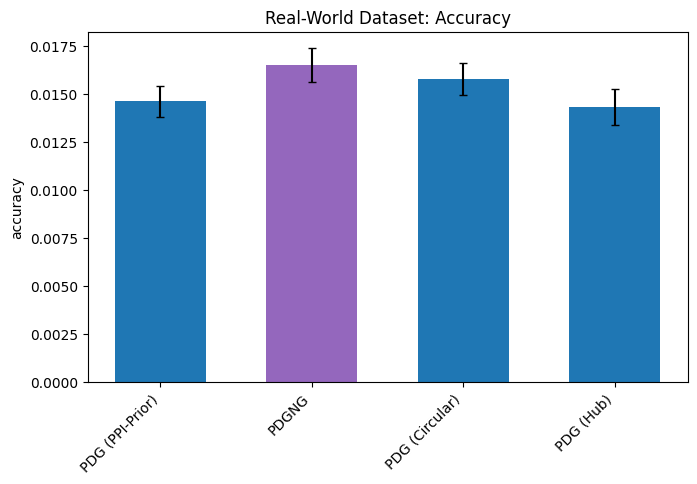

Displayed og pdgrapher data plot for 'pdgrapher': metric='accuracy' (normalize=False)
PDG (PPI-Prior): mean=0.191658398656215, std=0.01292382965770659
PDGNG: mean=0.20103345464725642, std=0.01530792352840937
PDG (Circular): mean=0.21068607689436356, std=0.01716444754554298
PDG (Hub): mean=0.21209101654846338, std=0.025821789986892697


/tmp/ipykernel_2512029/2283313594.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


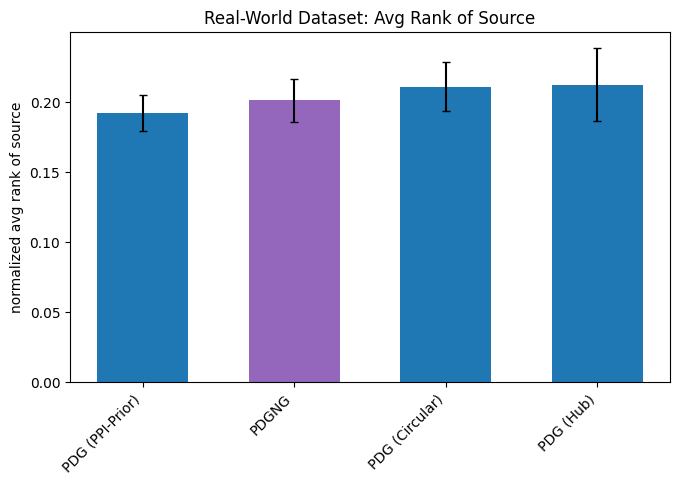

Displayed og pdgrapher data plot for 'pdgrapher': metric='avg rank of source' (normalize=True)
PDG (PPI-Prior): mean=0.101, std=0.004604345773288533
PDGNG: mean=0.098, std=0.0021213203435596446
PDG (Circular): mean=0.0945, std=0.008077747210701754
PDG (Hub): mean=0.09300000000000001, std=0.004546060565661956


/tmp/ipykernel_2512029/2283313594.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


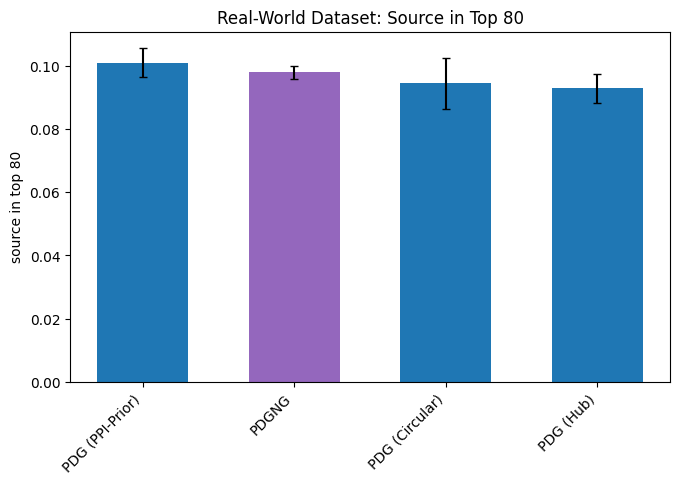

Displayed og pdgrapher data plot for 'pdgrapher': metric='source in top 80' (normalize=False)
PDG (PPI-Prior): mean=0.08824000000000001, std=0.0028548905408088752
PDGNG: mean=0.08795, std=0.0031260998064681165
PDG (Circular): mean=0.086925, std=0.0032475952641916415
PDG (Hub): mean=0.09076666666666666, std=0.0016131404843417153


/tmp/ipykernel_2512029/2283313594.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


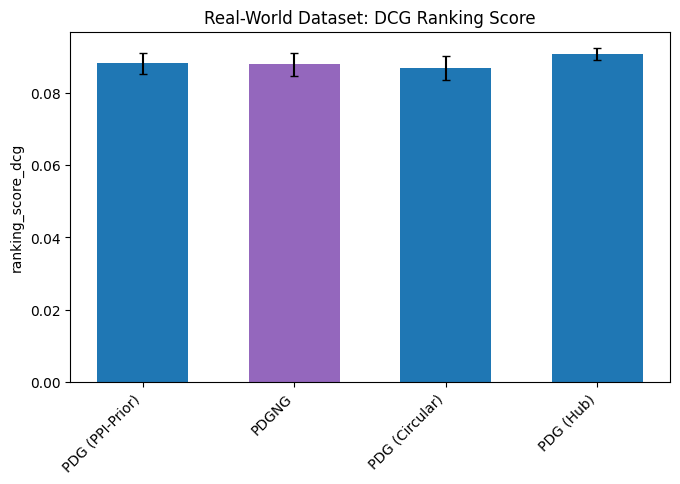

Displayed og pdgrapher data plot for 'pdgrapher': metric='ranking_score_dcg' (normalize=False)


In [ ]:
# og_pdgrapher_data("pdgrapher", "avg rank of source", normalize=True, title="OG PDGrapher Datasets: Avg Rank of Source (Normalized)")
og_pdgrapher_data("pdgrapher", "accuracy", normalize=False, title="Real-World Dataset: Accuracy")
og_pdgrapher_data("pdgrapher", "avg rank of source", normalize=True, title="Real-World Dataset: Avg Rank of Source")
# og_pdgrapher_data("pdgrapher", "source in top 20", normalize=False, title="OG PDGrapher Datasets: Source in Top 20")
og_pdgrapher_data("pdgrapher", "source in top 80", normalize=False, title="Real-World Dataset: Source in Top 80")
og_pdgrapher_data("pdgrapher", "ranking_score_dcg", normalize=False, title="Real-World Dataset: DCG Ranking Score", pdg_metric = True)